In [ ]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import xgboost as xgb

# Quick Overlook

In [3]:
train = pd.read_csv("data/train.csv", index_col=0)
test = pd.read_csv("data/test.csv", index_col=0)

x_train = train.drop(columns=["addicted_label"])
y_train = train["addicted_label"]

### Ordinal Encoding

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler

categorical_features = ["gender", "stress_level", "academic_work_impact"]
numerical_features = x_train.select_dtypes("float").columns.tolist()
log1p_scale_features = ["social_media_hours", "gaming_hours", "work_study_hours"]

categories = [
    ["Male", "Female", "Other"],
    ["Low", "Medium", "High"],
    ["No", "Yes"],
]

# Ordinal Encoding
ord_encoder = OrdinalEncoder(categories=categories,
                             handle_unknown="use_encoded_value",
                             unknown_value=np.nan,
                             encoded_missing_value=np.nan)
ord_encoder.set_output(transform="pandas")
ord_step = ColumnTransformer(
    transformers=[
        ("ordinal_encoding", ord_encoder, categorical_features),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)
ord_step.set_output(transform="pandas")

x_train_ord = ord_step.fit_transform(x_train)

# 1. Baseline XGB model

In [5]:
xgb_class = xgb.XGBClassifier(tree_method="hist", n_estimators=350, learning_rate=0.35)

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [7]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=11)
cv_scores_xgb_v1_1 = cross_val_score(cv=cv, estimator=xgb_class, X=x_train_ord, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb_v1_1)
print(cv_scores_xgb_v1_1.mean())
print(cv_scores_xgb_v1_1.std())

[0.96350764 0.96298303 0.96341454 0.96311877 0.96247437 0.96292087
 0.96260762 0.96241784 0.96280825 0.9633865 ]
0.9629639407531589
0.00037316438982995824


# 2. Preprocess data

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# Log1p Scaling
log1p_transformer = FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
    feature_names_out="one-to-one"
)
log1p_step = ColumnTransformer(
    transformers=[
        ("log1p_transform", log1p_transformer, log1p_scale_features),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)
log1p_step.set_output(transform="pandas")

# Standard Scaling globally
scaler_step = StandardScaler()

# Imputation mean -> num, mode -> cat
mean_imp = SimpleImputer(strategy="mean")
mode_imp = SimpleImputer(strategy="most_frequent")

imputation_step = ColumnTransformer(
    transformers=[
        ("numerical_imp", mean_imp, numerical_features),
        ("categorical_imp", mode_imp, categorical_features)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)
imputation_step.set_output(transform="pandas")

preprocessing = Pipeline([
    ("ordinal_encoding", ord_step),
    ("log1p_scaling", log1p_step),
    ("imputing", imputation_step),
])
preprocessing.set_output(transform="pandas")

x_train_prep = preprocessing.fit_transform(x_train)

In [9]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=11)
cv_scores_xgb_v1_1 = cross_val_score(cv=cv, estimator=xgb_class, X=x_train_prep, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb_v1_1)
print(cv_scores_xgb_v1_1.mean())
print(cv_scores_xgb_v1_1.std())

[0.96296601 0.96243335 0.96289001 0.96288781 0.96240121 0.96226511
 0.96240781 0.96198526 0.96243965 0.96286602]
0.9625542236296578
0.00031156323310268613


Preprocessing makes it more stable but worsens the score a little bit. In hyperparameter search i could add preprocessing step as a true or false.

# 3. Missingness indicator

In [10]:
from sklearn.impute import MissingIndicator

feature_cols = [col for col in x_train.columns if col != "id"]
indicator = MissingIndicator(features="all")

# Creates 0/1 binary indicator matrix for all feature columns
missing_matrix = indicator.fit_transform(x_train[feature_cols]).astype(int)
missing_flag_df = pd.DataFrame(
    missing_matrix,
    columns=[f"{col}_is_missing" for col in feature_cols],
    index=x_train.index,
)

In [11]:
missing_flag_df

,age_is_missing,daily_screen_time_hours_is_missing,social_media_hours_is_missing,gaming_hours_is_missing,work_study_hours_is_missing,sleep_hours_is_missing,notifications_per_day_is_missing,app_opens_per_day_is_missing,weekend_screen_time_is_missing,gender_is_missing,stress_level_is_missing,academic_work_impact_is_missing
id,,,,,,,,,,,,
0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,1,0,0,0
2,0,0,1,1,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
691364,0,0,0,0,0,0,0,0,0,0,1,0
691365,0,0,0,0,0,0,0,0,0,0,0,0
691366,1,1,1,1,0,0,1,0,0,0,0,0


In [12]:
x_train_ord_missing =  pd.concat([x_train_ord, missing_flag_df], axis=1)
x_train_prep_missing =  pd.concat([x_train_prep, missing_flag_df], axis=1)

In [13]:
# only ordinal encoding
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=11)
cv_scores_xgb_v1_1 = cross_val_score(cv=cv, estimator=xgb_class, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb_v1_1)
print(cv_scores_xgb_v1_1.mean())
print(cv_scores_xgb_v1_1.std())

[0.96350764 0.96298303 0.96341454 0.96311877 0.96247437 0.96292087
 0.96260762 0.96241784 0.96280825 0.9633865 ]
0.9629639407531589
0.00037316438982995824


In [14]:
# preprocessed x_train
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=11)
cv_scores_xgb_v1_1 = cross_val_score(cv=cv, estimator=xgb_class, X=x_train_prep_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb_v1_1)
print(cv_scores_xgb_v1_1.mean())
print(cv_scores_xgb_v1_1.std())

[0.96328563 0.96269506 0.9630886  0.96320507 0.96211369 0.96252975
 0.96253893 0.9623565  0.96263197 0.96294724]
0.962739241281146
0.0003627840664222088


# 4. Optuna optimization

In [15]:
import optuna
from sklearn.metrics import roc_auc_score

In [16]:
storage_name = "sqlite:///xgb_v1.db"
study_name = "xgb_search"

study_xgb1 = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction="maximize",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
)

[I 2026-09-16 17:42:43,873] Using an existing study with name 'xgb_search' instead of creating a new one.


In [17]:
def objective_xgb1(trial):
    # Preprocessing type
    use_preprocess = trial.suggest_categorical("use_preprocess", [True, False])
    use_missing_flag = trial.suggest_categorical("use_missing_flag", [True, False])

    if use_preprocess:
        if use_missing_flag:
            X = x_train_prep_missing
        else:
            X = x_train_prep
    else:
        if use_missing_flag:
            X = x_train_ord_missing
        else:
            X = x_train_ord

    # 3. Define XGBoost hyperparameters
    params = {
        "n_estimators": 1500,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),

        # tree composition
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-4, 10.0, log=True),

        # sampling
        "subsample": trial.suggest_float("subsample", 0.5, 1.0, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0, step=0.05),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0, step=0.1),

        # regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 50.0, log=True),

        # fixed
        "tree_method": "hist",
        "device": "cpu",
        "random_state": 11,
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "n_jobs":-1
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y_train)):
        # Split the chosen X dataset and the global y_train
        X_tr, y_tr = X.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y_train.iloc[val_idx]

        model = xgb.XGBClassifier(**params)
        
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        # Predict probabilities and calculate AUC
        val_probs = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, val_probs)
        fold_scores.append(score)
        
        # (Optional) Optuna Pruning: Abort bad trials early based on the first few folds
        trial.report(score, fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # 5. Return the mean AUC across all folds for Optuna to maximize
    return np.mean(fold_scores)

In [18]:
# study_xgb1.optimize(objective_xgb1, n_trials=1,  show_progress_bar=True, n_jobs=1)

# 5. Visuals and Model Selection

In [19]:
from optuna.visualization import plot_contour, plot_param_importances, plot_slice, plot_rank, plot_optimization_history

In [20]:
plot_slice(study_xgb1)

In [21]:
plot_param_importances(study_xgb1)

In [22]:
plot_rank(study_xgb1, params=["learning_rate", "min_child_weight", "max_depth", "use_preprocess"])

In [23]:
plot_optimization_history(study_xgb1)

In [24]:
study_xgb1.best_trials

[FrozenTrial(number=79, state=<TrialState.COMPLETE: 1>, values=[0.9644260408924044], datetime_start=datetime.datetime(2026, 8, 29, 15, 50, 53, 58748), datetime_complete=datetime.datetime(2026, 8, 29, 15, 54, 51, 856754), params={'use_preprocess': False, 'use_missing_flag': True, 'learning_rate': 0.06696421980195505, 'max_depth': 7, 'min_child_weight': 38.53988774196943, 'gamma': 0.0005169139118572665, 'subsample': 0.9, 'colsample_bytree': 0.45, 'colsample_bylevel': 1.0, 'reg_alpha': 0.00534194517394275, 'reg_lambda': 0.841148467319464}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9646560443178914, 1: 0.9647117058294973, 2: 0.9643002304987947, 3: 0.9640619430200826, 4: 0.9644002807957562}, distributions={'use_preprocess': CategoricalDistribution(choices=(True, False)), 'use_missing_flag': CategoricalDistribution(choices=(True, False)), 'learning_rate': FloatDistribution(high=0.2, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=15, log=False, low=3, step=1

In [25]:
x_train_ord_missing

,gender,stress_level,academic_work_impact,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,...,social_media_hours_is_missing,gaming_hours_is_missing,work_study_hours_is_missing,sleep_hours_is_missing,notifications_per_day_is_missing,app_opens_per_day_is_missing,weekend_screen_time_is_missing,gender_is_missing,stress_level_is_missing,academic_work_impact_is_missing
id,,,,,,,,,,,,,,,,,,,,,
0,0.0,1.0,0.0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,1.0,0.0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,...,0,1,0,0,0,0,1,0,0,0
2,1.0,0.0,1.0,18.0,5.09,NaN,NaN,NaN,6.25,134.0,...,1,1,1,0,0,0,0,0,0,0
3,2.0,0.0,NaN,21.0,6.42,1.26,1.42,3.36,8.85,112.0,...,0,0,0,0,0,0,0,0,0,1
4,1.0,1.0,0.0,26.0,11.20,1.87,2.81,1.95,5.25,NaN,...,0,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,0.0,NaN,0.0,22.0,10.78,3.25,1.57,1.65,7.71,86.0,...,0,0,0,0,0,0,0,0,1,0
691365,1.0,2.0,0.0,20.0,3.45,1.86,0.89,0.30,6.59,221.0,...,0,0,0,0,0,0,0,0,0,0
691366,2.0,1.0,0.0,NaN,NaN,NaN,NaN,2.06,6.16,NaN,...,1,1,0,0,1,0,0,0,0,0


In [26]:
best_trial_hyp = study_xgb1.best_params.copy()

In [27]:
best_trial_hyp.pop("use_preprocess")
best_trial_hyp.pop("use_missing_flag")


True

### First predictor

In [28]:
best_trial_xgb = xgb.XGBClassifier(**best_trial_hyp, n_estimators=1500)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
cv_scores_xgb1 = cross_val_score(cv=cv, estimator=best_trial_xgb, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb1)
print(cv_scores_xgb1.mean())
print(cv_scores_xgb1.std())

[0.96468219 0.96462396 0.96427788 0.96404983 0.96431233]
0.9643892388638198
0.00023427859746246634


### Second predictor

In [29]:
xgb2 = xgb.XGBClassifier(n_estimators=1500,
                                learning_rate=0.06,
                                max_depth=8,
                                min_child_weight=35,
                                gamma=0.0003,
                                subsample=0.9,
                                colsample_bylevel=1,
                                colsample_bytree=0.45,
                                reg_alpha=0.002)

cv_scores_xgb2 = cross_val_score(cv=cv, estimator=xgb2, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb2)
print(cv_scores_xgb2.mean())
print(cv_scores_xgb2.std())

[0.96461517 0.96466518 0.96424608 0.96405237 0.96438741]
0.9643932424583465
0.0002285100296401898


### Third predictor

In [30]:
xgb3_params = study_xgb1.trials[111].params.copy()
xgb3_params.pop("use_preprocess")
xgb3_params.pop("use_missing_flag")

xgb3 = xgb.XGBClassifier(n_estimators=1500, **xgb3_params)

cv_scores_xgb3 = cross_val_score(cv=cv, estimator=xgb3, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb3)
print(cv_scores_xgb3.mean())
print(cv_scores_xgb3.std())

[0.96466275 0.9645393  0.96425672 0.96392575 0.96434789]
0.9643464788630031
0.0002538808449732203


### Fourth model

In [31]:
xgb4_params = study_xgb1.trials[108].params.copy()
xgb4_params.pop("use_preprocess")
xgb4_params.pop("use_missing_flag")

xgb4 = xgb.XGBClassifier(n_estimators=1500, **xgb4_params)

cv_scores_xgb4 = cross_val_score(cv=cv, estimator=xgb4, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb4)
print(cv_scores_xgb4.mean())
print(cv_scores_xgb4.std())

[0.96468002 0.96460024 0.96427918 0.96391227 0.96434888]
0.9643641165376919
0.00027098411030504526


### 5 model

In [32]:
xgb5_params = study_xgb1.trials[93].params.copy()
xgb5_params.pop("use_preprocess")
xgb5_params.pop("use_missing_flag")

xgb5 = xgb.XGBClassifier(n_estimators=1500, **xgb5_params)

cv_scores_xgb5 = cross_val_score(cv=cv, estimator=xgb5, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_scores_xgb5)
print(cv_scores_xgb5.mean())
print(cv_scores_xgb5.std())

[0.9647075  0.96463729 0.9643776  0.96400648 0.96432208]
0.9644101889925054
0.00024970966644703957


# 6. VotingClassifier

In [33]:
from sklearn.ensemble import VotingClassifier

In [34]:
voting_clf = VotingClassifier(
    estimators=[
        ("xgb1", best_trial_xgb),
        ("xgb2", xgb2),
        ("xgb3", xgb3),
        ("xgb4", xgb4),
        ("xgb5", xgb5)
    ],
    voting="soft", 
    n_jobs=-1,
)
voting_clf.fit(x_train_ord_missing, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgb1', ...), ('xgb2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U34](24,)","['gender','stress_level','academic_work_impact',...,'gender_is_missing', 'stress_level_is_missing','academic_work_impact_is_missing']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [35]:
cv_voting_classifier = cross_val_score(cv=cv, estimator=voting_clf, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_voting_classifier)
print(cv_voting_classifier.mean())
print(cv_voting_classifier.std())

[0.96491628 0.96486662 0.96453324 0.96423769 0.96459335]
0.9646294369927052
0.0002459889880841117


# 7. Stacking Classifier

In [36]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [37]:
meta_learner1 = LogisticRegression(
    penalty="l2",
    C=0.1,
    solver="lbfgs",
    max_iter=2000,
    random_state=11,
)


stacking_clf = StackingClassifier(
    estimators=[
        ("xgb1", best_trial_xgb),
        ("xgb2", xgb2),
        ("xgb3", xgb3),
        ("xgb4", xgb4),
        ("xgb5", xgb5)
    ],
    final_estimator=meta_learner1,
    cv=5,  
    stack_method="predict_proba",  
    passthrough=False,  
    n_jobs=-1,
)

stacking_clf.fit(x_train_ord_missing, y_train)

KeyboardInterrupt: 

In [ ]:
cv_stacking_classifier = cross_val_score(cv=cv, estimator=stacking_clf, X=x_train_ord_missing, y=y_train, n_jobs=-1, scoring="roc_auc")
print(cv_stacking_classifier)
print(cv_stacking_classifier.mean())
print(cv_stacking_classifier.std())

/Users/homelab/Desktop/competitions/competitions/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/homelab/Desktop/competitions/competitions/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warni

[0.96491631 0.96484691 0.96453319 0.96423763 0.96459339]
0.964625485995172
0.00024231851443184653


# 8. Creating submissions

In [ ]:
test_ord = ord_step.fit_transform(test)

missing_matrix_test = indicator.fit_transform(test_ord[feature_cols]).astype(int)
missing_flag_df_test = pd.DataFrame(
    missing_matrix_test,
    columns=[f"{col}_is_missing" for col in feature_cols],
    index=test_ord.index,
)
test_ord_missing = pd.concat([test_ord, missing_flag_df_test], axis=1)

In [ ]:
best_trial_xgb.fit(x_train_ord_missing, y_train)
best_single_xgb_probability = best_trial_xgb.predict_proba(test_ord_missing)[:,1]
single_best_model = pd.DataFrame({"id": test_ord_missing.index, "addicted_label": best_single_xgb_probability})
single_best_model.to_csv("single_xgb_submission.csv", index=False)

In [ ]:
xgb5.fit(x_train_ord_missing, y_train)
xgb5_probability = xgb5.predict_proba(test_ord_missing)[:,1]
xgb5_df = pd.DataFrame({"id": test_ord_missing.index, "addicted_label": xgb5_probability})
xgb5_df.to_csv("xgb5_submission.csv", index=False)

In [ ]:
xgb2.fit(x_train_ord_missing, y_train)
xgb2_probability = xgb2.predict_proba(test_ord_missing)[:,1]
xgb2_df = pd.DataFrame({"id": test_ord_missing.index, "addicted_label": xgb2_probability})
xgb2_df.to_csv("xgb2_submission.csv", index=False)

In [ ]:
xgb3.fit(x_train_ord_missing, y_train)
xgb3_probability = xgb3.predict_proba(test_ord_missing)[:,1]
xgb3_df = pd.DataFrame({"id": test_ord_missing.index, "addicted_label": xgb3_probability})
xgb3_df.to_csv("xgb3_submission.csv", index=False)

In [ ]:
xgb4.fit(x_train_ord_missing, y_train)
xgb4_probability = xgb4.predict_proba(test_ord_missing)[:,1]
xgb4_df = pd.DataFrame({"id": test_ord_missing.index, "addicted_label": xgb4_probability})
xgb4_df.to_csv("xgb4_submission.csv", index=False)

In [ ]:
stacking_probability = stacking_clf.predict_proba(test_ord_missing)[:,1]
voting_probability = voting_clf.predict_proba(test_ord_missing)[:,1]

stacking_df = pd.DataFrame({"id": test_ord_missing.index, "addicted_label": stacking_probability})
stacking_df.to_csv("stacking_submission.csv", index=False)

voting_df = pd.DataFrame({"id": test_ord_missing.index, "addicted_label": voting_probability})
voting_df.to_csv("voting_submission.csv",index=False)

In [ ]:
stacking_clf.final_estimator_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",11
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To 

In [ ]:
meta_learner2 = LogisticRegression(
    penalty="l2",
    C=10,
    solver="lbfgs",
    max_iter=2000,
    random_state=11,
)


stacking_clf2 = StackingClassifier(
    estimators=[
        ("xgb1", best_trial_xgb),
        ("xgb2", xgb2),
        ("xgb3", xgb3),
        ("xgb4", xgb4),
        ("xgb5", xgb5)
    ],
    final_estimator=meta_learner2,
    cv=5,  
    stack_method="predict_proba",  
    passthrough=False,  
    n_jobs=-1,
)

stacking_clf2.fit(x_train_ord_missing, y_train)
stacking_clf2.final_estimator_

/Users/homelab/Desktop/competitions/competitions/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",11
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To c

# 9. Results

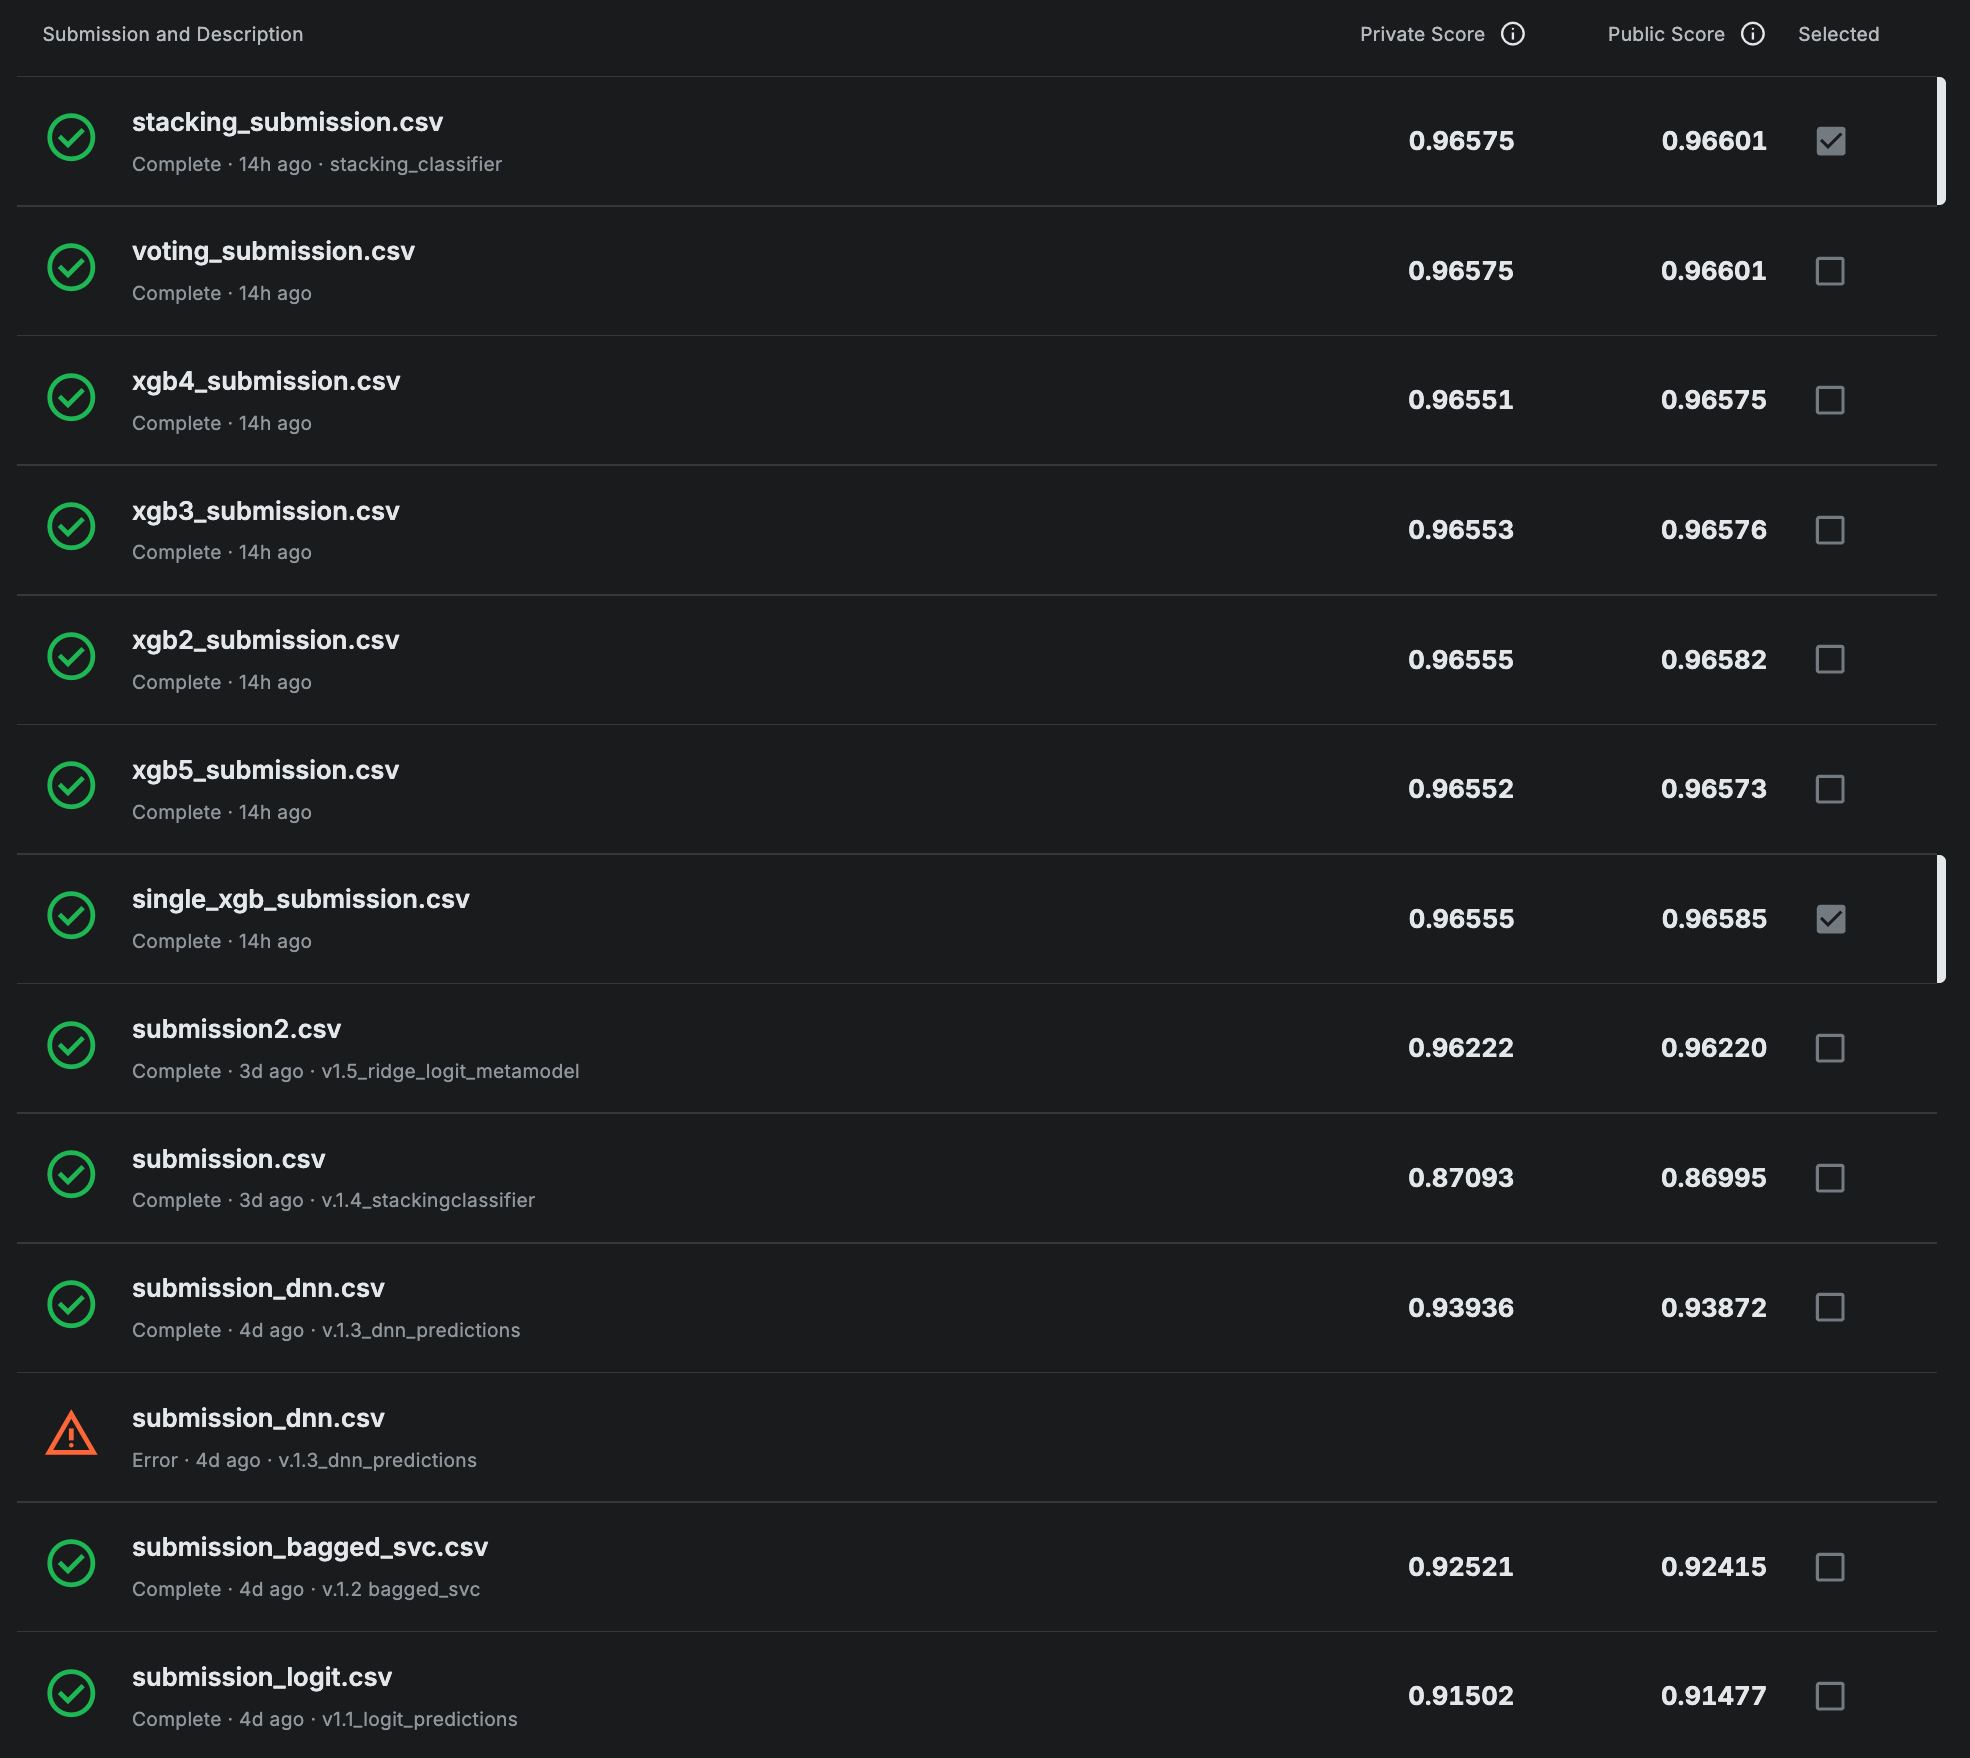